In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import zscore

In [3]:
df = pd.read_csv("student_performance_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'student_performance_dataset.csv'

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.describe()

In [ ]:
df.info

In [ ]:
print(df.dtypes)

# EDA

In [ ]:
plt.hist(df["Pass_Fail"],bins=3)

In [4]:
plt.hist(df["Past_Exam_Scores"],bins=10)

NameError: name 'df' is not defined

In [5]:
df["Pass_Fail"].value_counts()

NameError: name 'df' is not defined

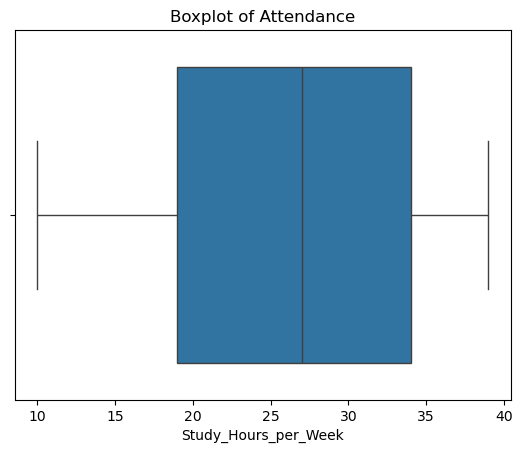

In [152]:
sns.boxplot(x=df["Study_Hours_per_Week"])
plt.title("Boxplot of Attendance")
plt.show()

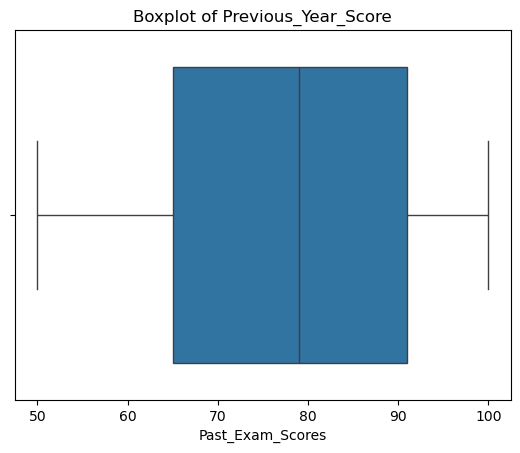

In [153]:
sns.boxplot(x=df["Past_Exam_Scores"])
plt.title("Boxplot of Previous_Year_Score")
plt.show()

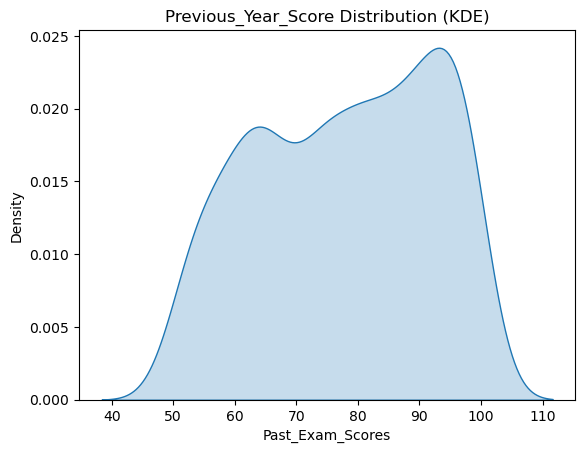

In [149]:
sns.kdeplot(df["Past_Exam_Scores"], fill=True)
plt.title("Previous_Year_Score Distribution (KDE)")
plt.show()

In [150]:
df["Past_Exam_Scores"].skew()

np.float64(-0.19202066877526483)

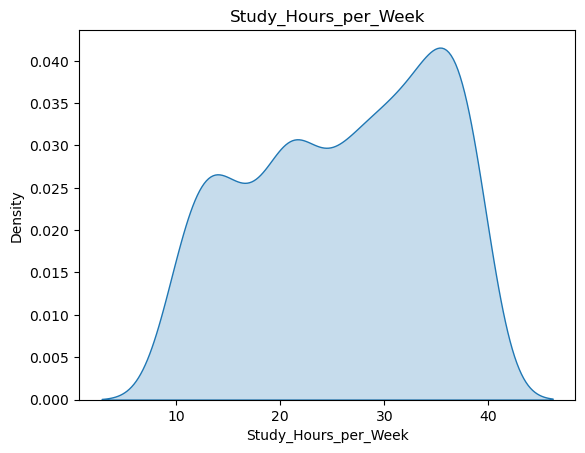

In [159]:
sns.kdeplot(df["Study_Hours_per_Week"], fill=True)
plt.title("Study_Hours_per_Week")
plt.show()

In [160]:
df["Study_Hours_per_Week"].skew()

np.float64(-0.23987004800747508)

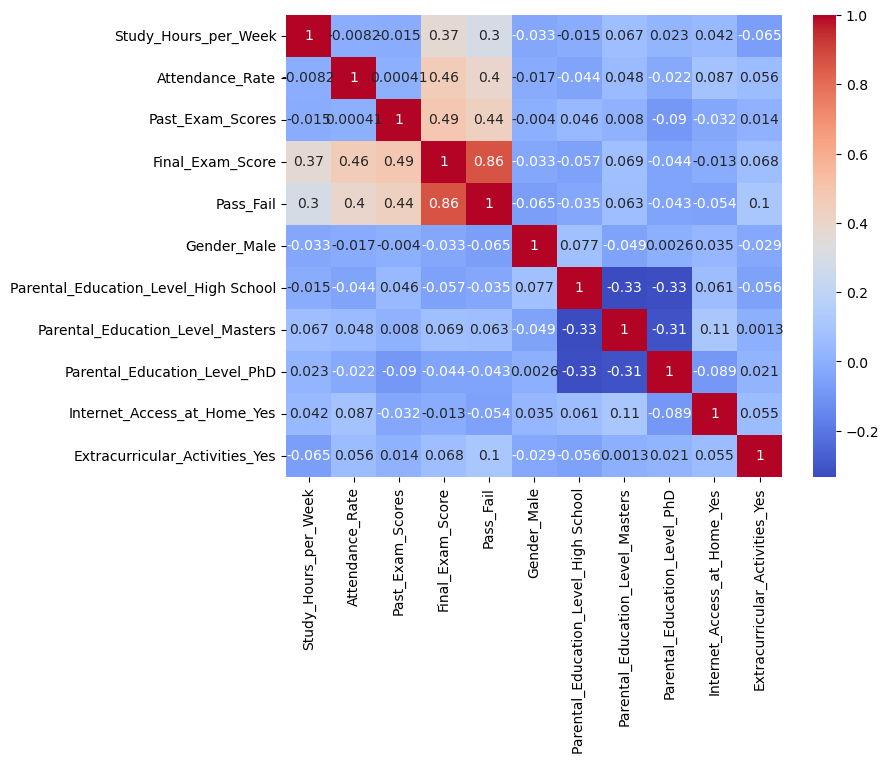

In [157]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Feature Transformation

In [161]:
df.isnull().sum()

Study_Hours_per_Week                    0
Attendance_Rate                         0
Past_Exam_Scores                        0
Final_Exam_Score                        0
Pass_Fail                               0
Gender_Male                             0
Parental_Education_Level_High School    0
Parental_Education_Level_Masters        0
Parental_Education_Level_PhD            0
Internet_Access_at_Home_Yes             0
Extracurricular_Activities_Yes          0
dtype: int64

# one hot encoding

In [120]:
import pandas as pd


# 📌 Apply One-Hot Encoding
df = pd.get_dummies(df, columns=[
    'Gender',
    'Parental_Education_Level',
    'Internet_Access_at_Home',
    'Extracurricular_Activities'
], drop_first=True)  # avoids dummy variable trap

print(df.head())

   Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  Final_Exam_Score  \
0                    31        68.267841                86                63   
1                    16        78.222927                73                50   
2                    21        87.525096                74                55   
3                    27        92.076483                99                65   
4                    37        98.655517                63                70   

  Pass_Fail  Gender_Male  Parental_Education_Level_High School  \
0      Pass         True                                  True   
1      Fail         True                                 False   
2      Fail        False                                 False   
3      Pass        False                                 False   
4      Pass        False                                 False   

   Parental_Education_Level_Masters  Parental_Education_Level_PhD  \
0                             False                  

In [121]:
df['Pass_Fail'] = df['Pass_Fail'].map({'Fail': 0, 'Pass': 1})

In [122]:
df

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score,Pass_Fail,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes
0,31,68.267841,86,63,1,True,True,False,False,True,True
1,16,78.222927,73,50,0,True,False,False,True,False,False
2,21,87.525096,74,55,0,False,False,False,True,True,False
3,27,92.076483,99,65,1,False,False,False,False,False,False
4,37,98.655517,63,70,1,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
703,14,84.658761,78,50,0,True,False,False,True,True,False
704,35,60.278990,83,62,1,True,False,True,False,False,False
705,25,98.384969,75,57,0,True,False,False,False,True,False
706,21,96.148012,84,65,1,False,False,False,False,True,False


In [134]:
from sklearn.model_selection import train_test_split

# 🔥 Convert True/False → 0/1
df = df.astype(int)

# 🎯 Features & Target
X = df.drop(["Pass_Fail","Final_Exam_Score"], axis=1)
y = df["Pass_Fail"]

# 🔀 Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ✅ Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (566, 9)
X_test shape: (142, 9)
y_train shape: (566,)
y_test shape: (142,)


In [135]:
X

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes
0,31,68,86,1,1,0,0,1,1
1,16,78,73,1,0,0,1,0,0
2,21,87,74,0,0,0,1,1,0
3,27,92,99,0,0,0,0,0,0
4,37,98,63,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
703,14,84,78,1,0,0,1,1,0
704,35,60,83,1,0,1,0,0,0
705,25,98,75,1,0,0,0,1,0
706,21,96,84,0,0,0,0,1,0


In [136]:
y

0      1
1      0
2      0
3      1
4      1
      ..
703    0
704    1
705    0
706    1
707    0
Name: Pass_Fail, Length: 708, dtype: int64

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [138]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (566, 9)
X_test : (142, 9)
y_train: (566,)
y_test : (142,)


In [139]:
X_train

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD,Internet_Access_at_Home_Yes,Extracurricular_Activities_Yes
65,22,93,88,0,1,0,0,0,0
72,26,59,52,1,1,0,0,0,1
262,26,52,58,1,0,1,0,1,1
514,31,90,56,0,0,0,1,1,0
113,33,91,53,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
534,10,72,89,1,1,0,0,0,1
584,23,85,72,1,0,0,1,1,0
493,30,67,67,0,1,0,0,0,0
527,10,96,97,1,0,0,1,1,0


In [140]:
y_train

65     1
72     0
262    0
514    0
113    0
      ..
534    0
584    0
493    0
527    0
168    0
Name: Pass_Fail, Length: 566, dtype: int64

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro')) 
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.8873239436619719
Precision: 0.8913620584031039
Recall: 0.8829170829170829
F1 Score: 0.885483870967742


In [145]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SGD": SGDClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=500),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}


# 📊 Loop through models
for name, model in models.items():
    print(f"\n🔹 {name}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='macro'))
    print("Recall:", recall_score(y_test, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_test, y_pred, average='macro'))


🔹 Logistic Regression
Accuracy: 0.8098591549295775
Precision: 0.8099206349206349
Recall: 0.8098591549295775
F1 Score: 0.8098497247433417

🔹 SGD
Accuracy: 0.5
Precision: 0.25
Recall: 0.5
F1 Score: 0.3333333333333333

🔹 KNN
Accuracy: 0.8169014084507042
Precision: 0.8191808191808192
Recall: 0.8169014084507042
F1 Score: 0.8165739268680445

🔹 Naive Bayes
Accuracy: 0.8169014084507042
Precision: 0.8191808191808192
Recall: 0.8169014084507042
F1 Score: 0.8165739268680445

🔹 Decision Tree
Accuracy: 0.8943661971830986
Precision: 0.9008064516129033
Recall: 0.8943661971830985
F1 Score: 0.8939401483842055

🔹 Random Forest


C:\Users\Moham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.9154929577464789
Precision: 0.9208358448864777
Recall: 0.9154929577464789
F1 Score: 0.915223880597015

🔹 Extra Trees
Accuracy: 0.9154929577464789
Precision: 0.9208358448864777
Recall: 0.9154929577464789
F1 Score: 0.915223880597015

🔹 Gradient Boosting
Accuracy: 0.8661971830985915
Precision: 0.8662698412698413
Recall: 0.8661971830985915
F1 Score: 0.8661905470416109

🔹 AdaBoost
Accuracy: 0.8309859154929577
Precision: 0.832039800995025
Recall: 0.8309859154929577
F1 Score: 0.8308516974389517

🔹 SVM
Accuracy: 0.8380281690140845
Precision: 0.8386327503974562
Recall: 0.8380281690140845
F1 Score: 0.8379558422227735

🔹 LDA
Accuracy: 0.8309859154929577
Precision: 0.8312487591820528
Recall: 0.8309859154929577
F1 Score: 0.830952380952381

🔹 QDA
Accuracy: 0.8309859154929577
Precision: 0.832039800995025
Recall: 0.8309859154929577
F1 Score: 0.8308516974389517

🔹 MLP
Accuracy: 0.7887323943661971
Precision: 0.7908091908091908
Recall: 0.7887323943661972
F1 Score: 0.7883545310015898

🔹 XGBoos

C:\Users\Moham\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:47:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 283, number of negative: 283
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 267
[LightGBM] [Info] Number of data points in the train set: 566, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [45]:
!pip install lightgbm

In [1]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NameError: name 'X_train' is not defined

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import joblib

# Load your dataset
df = pd.read_csv("student_performance_dataset.csv")

In [10]:
# One-Hot Encoding (exact same as your code)
df = pd.get_dummies(df, columns=[
    'Gender',
    'Parental_Education_Level',
    'Internet_Access_at_Home',
    'Extracurricular_Activities'
], drop_first=True)

# Encode target
df['Pass_Fail'] = df['Pass_Fail'].map({'Fail': 0, 'Pass': 1})

# Convert True/False → 0/1
df = df.astype(int)

# Features & Target
X = df.drop(["Pass_Fail", "Final_Exam_Score"], axis=1)
y = df["Pass_Fail"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

KeyError: "None of [Index(['Gender', 'Parental_Education_Level', 'Internet_Access_at_Home',\n       'Extracurricular_Activities'],\n      dtype='object')] are in the [columns]"